In [5]:
from sklearn.datasets import load_breast_cancer
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

dataset = load_breast_cancer()

df = pd.DataFrame(dataset.data , columns = dataset.feature_names)

df['target'] = dataset.target

print(df.shape)
print(df.head())
print(dataset.target_names)

(569, 31)
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimeter  worst area  \
0   

In [6]:
from sklearn.model_selection import train_test_split
X = df.drop(columns = ['target'])
y = df['target']

X_train , X_test , y_train , y_test = train_test_split(X,y,test_size = 0.2 , random_state = 42)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(455, 30)
(114, 30)
(455,)
(114,)


In [13]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(random_state = 42)
model.fit(X_train , y_train)
y_pred = model.predict(X_test)
print(y_pred[:10])

[1 0 0 1 1 0 0 0 0 1]


In [15]:
from sklearn.metrics import accuracy_score , precision_score , f1_score , confusion_matrix , recall_score

print("Accuracy Score :" , accuracy_score(y_test , y_pred))
print("Precision Score :" , precision_score(y_test , y_pred))
print("F1 Score :" , f1_score(y_test , y_pred))
print("Confusion Matrix :" , confusion_matrix(y_test , y_pred))
print("Recall Score :" , recall_score(y_test , y_pred))

Accuracy Score : 0.9473684210526315
Precision Score : 0.9577464788732394
F1 Score : 0.9577464788732394
Confusion Matrix : [[40  3]
 [ 3 68]]
Recall Score : 0.9577464788732394


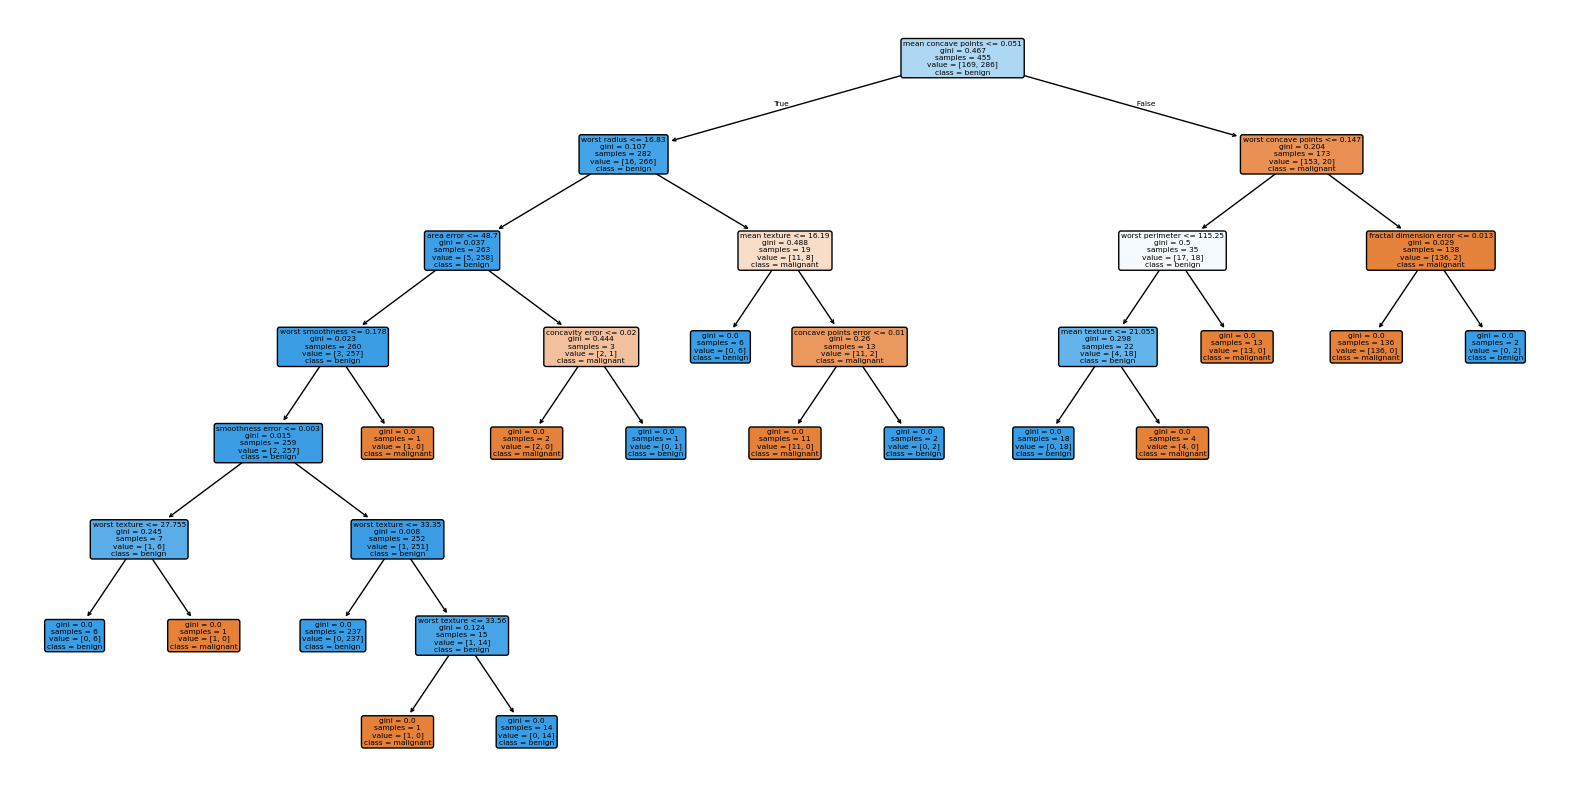

In [25]:
from sklearn.tree import plot_tree
plt.figure(figsize = (20,10))
plot_tree( model ,
           feature_names = X.columns , 
           class_names = dataset.target_names , 
           filled = True , 
           rounded = True)

plt.show()


In [29]:
for i in [1,3,5,None]:
    model = DecisionTreeClassifier(random_state = 42 , max_depth = i)    
    model.fit(X_train , y_train)
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    print("Max Depth :" , {i})
    print("Accuracy Score :" , accuracy_score(y_train , train_pred))
    print("Accuracy Score :" , accuracy_score(y_test , test_pred))

Max Depth : {1}
Accuracy Score : 0.9208791208791208
Accuracy Score : 0.8947368421052632
Max Depth : {3}
Accuracy Score : 0.978021978021978
Accuracy Score : 0.9473684210526315
Max Depth : {5}
Accuracy Score : 0.9956043956043956
Accuracy Score : 0.9473684210526315
Max Depth : {None}
Accuracy Score : 1.0
Accuracy Score : 0.9473684210526315


In [31]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators = 100 , random_state = 42)
model.fit(X_train , y_train)
y_pred = model.predict(X_test)
print("Accuracy Score : " , accuracy_score(y_test, y_pred))
print("Precision Score : " , precision_score(y_test, y_pred))
print("Recall Score : " , recall_score(y_test, y_pred))
print("F1 Score : " , f1_score(y_test, y_pred))
print("Confusion Matrix : " , confusion_matrix(y_test, y_pred))

Accuracy Score :  0.9649122807017544
Precision Score :  0.958904109589041
Recall Score :  0.9859154929577465
F1 Score :  0.9722222222222222
Confusion Matrix :  [[40  3]
 [ 1 70]]


In [35]:
importance = model.feature_importances_
df_feature = pd.DataFrame({"feature " : X.columns, "Importance" : importance})
df_feature.sort_values(by = "Importance",ascending = False)
df_feature.head(10)

,feature,Importance
0,mean radius,0.048703
1,mean texture,0.013591
2,mean perimeter,0.053270
3,mean area,0.047555
4,mean smoothness,0.007285
5,mean compactness,0.013944
6,mean concavity,0.068001
7,mean concave points,0.106210
8,mean symmetry,0.003770
9,mean fractal dimension,0.003886


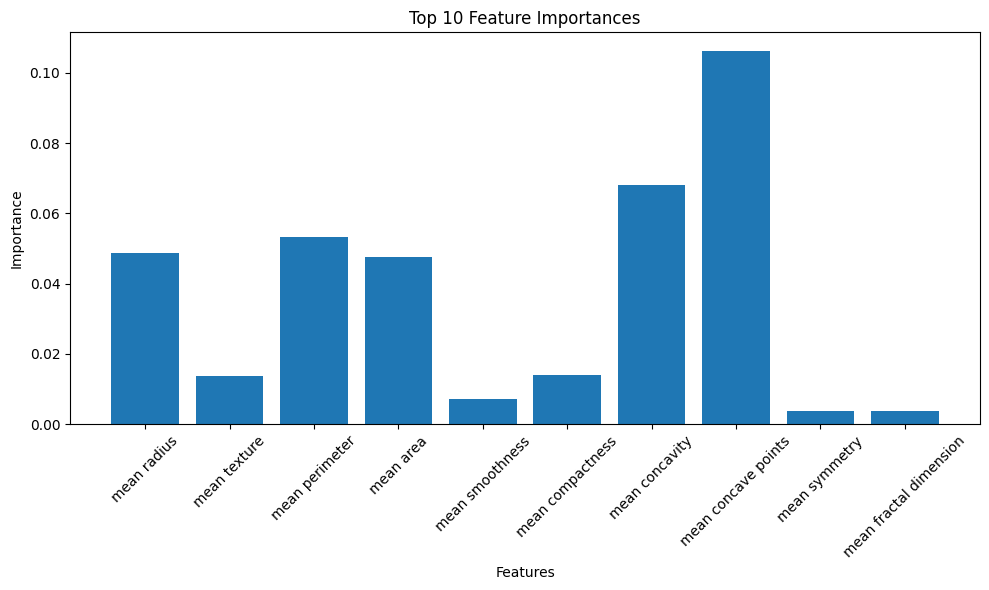

In [49]:
import matplotlib.pyplot as plt

# Top 10 features
top10 = df_feature.head(10)
top10
plt.figure(figsize=(10, 6))

plt.bar(top10["feature "], top10["Importance"])

plt.xticks(rotation=45)
plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Top 10 Feature Importances")

plt.tight_layout()
plt.show()

In [56]:
for i in [10 , 50 , 100 , 200]:
    model = RandomForestClassifier(n_estimators = i)

    model.fit(X_train , y_train)

    y_pred = model.predict(X_test)
    print("Number of Trees is :" , i)
    print("Accuracy :" , accuracy_score(y_test , y_pred))

Number of Trees is : 10
Accuracy : 0.9473684210526315
Number of Trees is : 50
Accuracy : 0.956140350877193
Number of Trees is : 100
Accuracy : 0.9649122807017544
Number of Trees is : 200
Accuracy : 0.9649122807017544


In [58]:
for i in [2,5,10,None]:
    model = RandomForestClassifier(n_estimators = 100, max_depth = i)

    model.fit(X_train , y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    print("Max Deapth :" , i)
    print("Training Accuracy :" , accuracy_score(y_train , train_pred))
    print("Testing Accuracy :" , accuracy_score(y_test , test_pred))

Max Deapth : 2
Training Accuracy : 0.9648351648351648
Testing Accuracy : 0.9649122807017544
Max Deapth : 5
Training Accuracy : 0.9934065934065934
Testing Accuracy : 0.9649122807017544
Max Deapth : 10
Training Accuracy : 1.0
Testing Accuracy : 0.9649122807017544
Max Deapth : None
Training Accuracy : 1.0
Testing Accuracy : 0.9649122807017544


In [59]:
for i in [2,5,10,20]:
    model = RandomForestClassifier(n_estimators = 100, random_state = 42 ,min_samples_split = i)

    model.fit(X_train , y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    print("Min samples split :" , i)
    print("Training Accuracy :" , accuracy_score(y_train , train_pred))
    print("Testing Accuracy :" , accuracy_score(y_test , test_pred))

Min samples split : 2
Training Accuracy : 1.0
Testing Accuracy : 0.9649122807017544
Min samples split : 5
Training Accuracy : 0.9956043956043956
Testing Accuracy : 0.9649122807017544
Min samples split : 10
Training Accuracy : 0.9912087912087912
Testing Accuracy : 0.9649122807017544
Min samples split : 20
Training Accuracy : 0.9824175824175824
Testing Accuracy : 0.9649122807017544
